# NAS - Optuna

- **Authored by:** Matheus Ferreira Silva 
- **GitHub:**: https://github.com/MatheusFS-dev

### **Data Summary**

- **beam_output**  
  - **Shape:** (9638, 8, 32)  
  - **Represents:** Target labels representing beam scores for each sample.  
  - **Example:** For one sample, a portion of the beam scores might look like:  
    ```
    [[1.51e-06, 1.76e-06, 3.01e-06, ...], 
     [1.77e-06, 2.02e-06, 3.37e-06, ...], 
     ...]
    ```  
    Each value is a float (with an imaginary part of zero), indicating the quality of a specific beam pair.

- **coord_input**  
  - **Shape:** (9638, 2)  
  - **Represents:** 2D coordinates associated with each sample (e.g., spatial positions).  
  - **Example:** The first sample might have coordinates similar to:  
    ```
    [748.92, 624.72]
    ```

- **image_input**  
  - **Shape:** (9638, 48, 81, 1)  
  - **Represents:** Grayscale image data where each pixel is an 8-bit unsigned integer.  
  - **Example:** A snippet from the first image might include pixel values such as:  
    ```
    [[[156], [136], [119], ...],
     [[131], [105], [91], ...],
     [[153], [116], [100], ...],
     ...]
    ```

- **lidar_input**  
  - **Shape:** (9638, 20, 200, 10)  
  - **Represents:** LIDAR data formatted as a multi-channel grid (20×200 with 10 channels), encoding spatial features or intensities. This representation indicates that LIDAR data contains spatial information about obstructions, base stations, and the target vehicle, which can be crucial for predicting beamforming paths.
  - **Semantic Meaning of Voxel Values:**  
    - **-2:** Base Station (BS) location  
    - **-1:** Target vehicle (receiver)  
    - **1:** Obstacles (e.g., other vehicles, buildings, pedestrians, trees)  
    - **0:** Empty space (free path for mmWave signals)  
  - **Example:**  
    ```
    [[[0, 0, 0, ..., 0, 0, 0],
      [0, 0, 0, ..., 0, 0, 0],
      ...,
      [-2, -1, 1, ..., 0, 0, 0]],
     ...]
    ```

## 1. Imports

In [1]:
%pip install numpy scipy scikit-learn optuna fireducks optuna-integration

# ———————————————————————————— Standard Libraries ———————————————————————————— #
import os, gc, math, signal, shutil, traceback, subprocess

# Async CUDA allocator
# https://docs.nvidia.com/deeplearning/frameworks/tensorflow-user-guide/index.html#tf_gpu_allocator
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'


from IPython.display import clear_output, display, HTML, Image

# ———————————————————————————————— Annotations ——————————————————————————————— #
from typing import *

# ————————————————————————— Data Processing Libraries ———————————————————————— #
import numpy as np
import fireducks.pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ——————————————————————— TensorFlow and Keras Modules ——————————————————————— #
import tensorflow as tf
from tensorflow.keras.backend import clear_session
from tensorflow.keras import (
    layers,
    Model,
    callbacks,
    optimizers,
    regularizers,
    metrics,
    losses,
    mixed_precision,
)
from tensorflow.python.profiler.model_analyzer import profile
from tensorflow.python.profiler.option_builder import ProfileOptionBuilder

# Set TensorFlow logger level to ERROR
tf.get_logger().setLevel('ERROR')


# ——————————————————————————— Scikit-learn Modules ——————————————————————————— #
from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    RobustScaler,
    QuantileTransformer,
    PowerTransformer,
)
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# —————————————————————————————————— Optuna —————————————————————————————————— #
import optuna
from optuna.integration import KerasPruningCallback
# import optunahub  # For the AutoSampler

# ——————————————————————————————— Local Import ——————————————————————————————— #
from utils.email_api import notify_training_success, notify_warning


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.


2025-04-24 13:55:07.491807: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-24 13:55:07.502773: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745513707.515090   50646 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745513707.518679   50646 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-24 13:55:07.531391: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

## 2. Utility Functions Definitions

### 2.1. GPU

In [2]:
def get_gpu_info() -> None:
    """
    Prints TensorFlow version, CUDA/cuDNN versions, and GPU availability.

    Raises:
        ImportError: If TensorFlow is not installed.
    """
    print(f"TensorFlow Version: {tf.__version__}")

    if tf.test.is_built_with_cuda():
        build_info = tf.sysconfig.get_build_info()
        print("CUDA support detected")
        print(f"  CUDA Version: {build_info.get('cuda_version', 'Unknown')}")
        print(f"  cuDNN Version: {build_info.get('cudnn_version', 'Unknown')}")
    else:
        print("No CUDA support (CPU only)")

    gpus = tf.config.list_physical_devices("GPU")
    if gpus:
        print(f"\nGPUs Detected ({len(gpus)}): {[gpu.name for gpu in gpus]}")
        print(f"Default GPU device: {tf.test.gpu_device_name()}")
    else:
        print("No GPUs found (CPU execution)")

### 2.2. Folder and Files

In [3]:
def create_run_directory(prefix: str, base_dir: str = "runs") -> str:
    """
    Creates and returns a new run directory with an incremented suffix.

    Args:
        prefix (str): Prefix for the run directory name.
        base_dir (str, optional): Base path where run directories are created.
                                  Defaults to "runs".

    Returns:
        str: Full path to the created run directory.
    """
    os.makedirs(base_dir, exist_ok=True)

    existing = [
        int(d[len(prefix):]) for d in os.listdir(base_dir)
        if d.startswith(prefix) and d[len(prefix):].isdigit()
    ]
    run_number = (max(existing) if existing else 0) + 1
    run_dir = os.path.join(base_dir, f"{prefix}{run_number}")
    os.makedirs(run_dir)

    return run_dir

In [4]:
def save_trial_params_to_file(filepath: str, params: dict[str, float], **kwargs: str) -> None:
    """
    Save trial parameters and additional metadata to a text file.

    Args:
        filepath (str): Destination path for the file.
        params (dict[str, float]): Trial parameters to be saved.
        **kwargs (str): Additional metadata (e.g., trial ID, rank, loss).
    """
    with open(filepath, "w") as file:
        file.writelines(f"{k}: {v}\n" for k, v in kwargs.items())
        file.write("Parameters:\n")
        file.writelines(f"  {k}: {v}\n" for k, v in params.items())

### 2.3. Study Utils

In [5]:
def analyze_study(
    study: optuna.Study,
    fig_dir: str,
    table_dir: Optional[str] = None,
    top_frac: float = 0.2
) -> None:
    """Analyze an Optuna study with robust, performance-driven insights.

    - Renames `value` → `loss`.
    - Replaces non-finite (±inf) or NaN losses with the worst finite loss.
    - Summarizes numeric and categorical hyperparameters overall,
      for the top `top_frac` trials (by lowest loss) and
      bottom `top_frac` trials (by highest loss).
    - Ranks numeric parameters by Pearson |corr| with loss and
      scatter-plots the top 6.
    - Saves all summary tables as CSV into `table_dir` (defaults to `fig_dir`).
    - Saves all figures into `fig_dir`.

    Args:
        study: A completed Optuna Study object.
        fig_dir: Directory in which to save plots.
        table_dir: Directory in which to save CSV summary tables.
                   If None, uses `fig_dir`.
        top_frac: Fraction of trials to consider in “top” and “bottom”
                  groups for performance-stratified summaries (0 < top_frac < 1).

    Returns:
        None. Displays HTML tables and saves CSVs and figures.
    """
    # Prepare directories
    os.makedirs(fig_dir, exist_ok=True)
    if table_dir is None:
        table_dir = fig_dir
    os.makedirs(table_dir, exist_ok=True)

    # 1) Count failed trials
    failed = sum(
        1 for t in study.trials
        if t.state != optuna.trial.TrialState.COMPLETE
    )
    print(f"Number of failed trials: {failed}\n")

    # 2) Build DataFrame of completed trials
    df = (
        study.trials_dataframe(attrs=("number", "value", "state", "params"))
             .query("state == 'COMPLETE'")
             .drop(columns=["number", "state"], errors="ignore")
    )
    if df.empty:
        print("No completed trials to analyze.")
        return

    # 3) Rename 'value' → 'loss'
    df = df.rename(columns={"value": "loss"})

    # 4) Replace infinite and NaN losses
    finite_losses = df["loss"].replace([np.inf, -np.inf], np.nan)
    worst_loss = finite_losses.max()
    df["loss"] = (
        df["loss"]
        .replace([np.inf, -np.inf], worst_loss)
        .fillna(worst_loss)
    )

    # 5) Separate numeric vs categorical parameters
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    numeric_cols.remove("loss")
    categorical_cols = df.select_dtypes(include="object").columns.tolist()

    # Helper to describe numeric columns
    def describe_numeric(data: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
        stats = []
        for col in cols:
            arr = data[col]
            stats.append({
                "Parameter": col,
                "Mean": arr.mean(),
                "Std": arr.std(),
                "Min": arr.min(),
                "25%": arr.quantile(0.25),
                "Median": arr.median(),
                "75%": arr.quantile(0.75),
                "Max": arr.max(),
            })
        return pd.DataFrame(stats)

    # 6) Overall numeric summary
    overall_num = describe_numeric(df, numeric_cols)
    display(HTML("<h3>Overall Numeric Hyperparameter Summary</h3>"))
    display(overall_num)
    overall_num.to_csv(
        os.path.join(table_dir, "overall_numeric_summary.csv"),
        index=False
    )

    # 7) Split into top/bottom trials by loss
    n = max(1, int(len(df) * top_frac))
    best_df = df.nsmallest(n, "loss")
    worst_df = df.nlargest(n, "loss")

    best_num = describe_numeric(best_df, numeric_cols)
    worst_num = describe_numeric(worst_df, numeric_cols)

    display(HTML(f"<h3>Top {int(top_frac*100)}% Trials Numeric Summary (lowest loss)</h3>"))
    display(best_num)
    best_num.to_csv(
        os.path.join(table_dir, "best_numeric_summary.csv"),
        index=False
    )

    display(HTML(f"<h3>Bottom {int(top_frac*100)}% Trials Numeric Summary (highest loss)</h3>"))
    display(worst_num)
    worst_num.to_csv(
        os.path.join(table_dir, "worst_numeric_summary.csv"),
        index=False
    )

    # 8) Categorical frequency tables
    def freq_table(data: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
        rows = []
        for col in cols:
            counts = data[col].value_counts(normalize=True)
            for cat, frac in counts.items():
                rows.append({
                    "Parameter": col,
                    "Category": cat,
                    "Fraction": frac,
                    "Count": int(data[col].value_counts()[cat]),
                })
        return pd.DataFrame(rows)

    overall_cat = freq_table(df, categorical_cols)
    best_cat = freq_table(best_df, categorical_cols)
    worst_cat = freq_table(worst_df, categorical_cols)

    display(HTML("<h3>Overall Categorical Frequencies</h3>"))
    display(overall_cat)
    overall_cat.to_csv(
        os.path.join(table_dir, "overall_categorical_frequencies.csv"),
        index=False
    )

    display(HTML(f"<h3>Top {int(top_frac*100)}% Trials Categorical Frequencies</h3>"))
    display(best_cat)
    best_cat.to_csv(
        os.path.join(table_dir, "best_categorical_frequencies.csv"),
        index=False
    )

    display(HTML(f"<h3>Bottom {int(top_frac*100)}% Trials Categorical Frequencies</h3>"))
    display(worst_cat)
    worst_cat.to_csv(
        os.path.join(table_dir, "worst_categorical_frequencies.csv"),
        index=False
    )

    # 9) Numeric parameter correlations with loss
    corr = (
        df[numeric_cols + ["loss"]]
        .corr()["loss"]
        .abs()
        .drop("loss")
        .sort_values(ascending=False)
    )
    corr_df = corr.to_frame(name="|corr|").reset_index().rename(columns={"index": "Parameter"})
    display(HTML("<h3>Numeric Parameter Correlation (|r|) with Loss</h3>"))
    display(corr_df)
    corr_df.to_csv(
        os.path.join(table_dir, "numeric_correlation_with_loss.csv"),
        index=False
    )

    # 10) Scatter-plots for top 6 correlated parameters
    top_params = corr.head(6).index.tolist()
    if top_params:
        rows = math.ceil(len(top_params) / 3)
        fig, axes = plt.subplots(rows, 3, figsize=(6 * 3, 4 * rows))
        axes = axes.flatten()
        for i, col in enumerate(top_params):
            ax = axes[i]
            ax.scatter(df[col], df["loss"], alpha=0.6, s=12)
            ax.set(title=f"{col} vs loss", xlabel=col, ylabel="loss")
            ax.grid(True)
        for ax in axes[len(top_params):]:
            fig.delaxes(ax)
        plt.tight_layout()
        fig.savefig(os.path.join(fig_dir, "top_corr_scatter.png"))
        plt.show()
        plt.close(fig)

    # 11) Loss distribution histogram
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(df["loss"], bins=25, edgecolor="black")
    ax.set(title="Loss Distribution", xlabel="loss", ylabel="Frequency")
    plt.tight_layout()
    fig.savefig(os.path.join(fig_dir, "loss_histogram.png"))
    plt.show()
    plt.close(fig)

## 3. Setup and Configuration

### 3.1. GPU Management

In [6]:
# Specify GPU to use (e.g., GPU 0)
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
get_gpu_info()

TensorFlow Version: 2.18.0
CUDA support detected
  CUDA Version: 12.5.1
  cuDNN Version: 9

GPUs Detected (1): ['/physical_device:GPU:0']
Default GPU device: /device:GPU:0


I0000 00:00:1745513708.968967   50646 gpu_process_state.cc:201] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1745513708.969127   50646 gpu_device.cc:2022] Created device /device:GPU:0 with 2229 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


### 3.2. Run Parameters 

In [ ]:
NUM_TRIALS = 500
EPOCHS = 50
TOP_K = 10  # Number of top trials to save

mixed_precision.set_global_policy("mixed_float16")

#? Set to an existing path to resume training
RESUME_TRAINING_PATH = "runs/nas_concat_inputs_1" # None or "runs/nas_1" 

In [8]:
RUN_DIR = RESUME_TRAINING_PATH or create_run_directory(prefix="nas_concat_inputs_")
print(f"Run directory: {RUN_DIR}")

Run directory: runs/nas_concat_inputs_1


## 4. Data Loading and Preprocessing

In [9]:
def convert_to_sparse_labels(y: np.ndarray) -> np.ndarray:
    """
    Converts beam score targets to sparse integer labels suitable for SparseCategoricalCrossentropy loss.

    Args:
        y (np.ndarray): Original beam scores with shape (N, 8, 32).

    Returns:
        np.ndarray: Array of integer labels with shape (N,), where each label corresponds 
                    to the index (flattened over 8x32) of the maximum score.
    """
    # Reshape the input so that each sample becomes a 1D array (e.g., 256 elements)
    y_flat = y.reshape(y.shape[0], -1)
    # For each sample, return the index of the maximum value
    labels = np.argmax(y_flat, axis=1)
    return labels


In [10]:
# Define the base directory for data files
DATA_DIR = "./data/s008"

# Construct full paths to the .npy files
beam_output_path = os.path.join(DATA_DIR, "beam_output", "output_classification.npy")
coord_input_path = os.path.join(DATA_DIR, "coord_input", "coordinates.npy")
image_input_path = os.path.join(DATA_DIR, "image_input", "inputs.npy")
lidar_input_path = os.path.join(DATA_DIR, "lidar_input", "input.npy")

# Load the data from the .npy files
s008_y_train = np.load(beam_output_path)
s008_coord_input = np.load(coord_input_path)
s008_image_input = np.load(image_input_path)
s008_lidar_input = np.load(lidar_input_path)

# Cast target beam outputs to float - REMOVING USELESS IMAG PART
s008_y_train = s008_y_train.astype(np.float32)
s008_coord_input = s008_coord_input.astype(np.float32)

print(f"Shape before conversion: {s008_y_train.shape}")
s008_y_train = convert_to_sparse_labels(s008_y_train)
print(f"Shape after conversion: {s008_y_train.shape}")

# Print the shapes of the loaded data
print(f"y_train shape: {s008_y_train.shape}")
print(f"coord_input shape: {s008_coord_input.shape}")
print(f"image_input shape: {s008_image_input.shape}")
print(f"lidar_input shape: {s008_lidar_input.shape}")

Shape before conversion: (1960, 8, 32)
Shape after conversion: (1960,)
y_train shape: (1960,)
coord_input shape: (1960, 2)
image_input shape: (1960, 48, 81, 1)
lidar_input shape: (1960, 20, 200, 10)


/tmp/ipykernel_50646/1378391195.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  s008_y_train = s008_y_train.astype(np.float32)


In [ ]:
# Define the base directory for data files
DATA_DIR = "./data/s009"

# Construct full paths to the .npy files
beam_output_path = os.path.join(DATA_DIR, "beam_output", "output_classification.npy")
coord_input_path = os.path.join(DATA_DIR, "coord_input", "coordinates.npy")
image_input_path = os.path.join(DATA_DIR, "image_input", "inputs.npy")
lidar_input_path = os.path.join(DATA_DIR, "lidar_input", "input.npy")

# Load the data from the .npy files
s009_y = np.load(beam_output_path)
s009_coord_input = np.load(coord_input_path)
s009_image_input = np.load(image_input_path)
s009_lidar_input = np.load(lidar_input_path)

# Cast target beam outputs to float - REMOVING USELESS IMAG PART
s009_y = s009_y.astype(np.float32)
s009_coord_input = s009_coord_input.astype(np.float32)

print(f"Shape before conversion: {s009_y.shape}")
s009_y = convert_to_sparse_labels(s009_y)
print(f"Shape after conversion: {s009_y.shape}")

# Print the shapes of the loaded data
print(f"y_train shape: {s009_y.shape}")
print(f"coord_input shape: {s009_coord_input.shape}")
print(f"image_input shape: {s009_image_input.shape}")
print(f"lidar_input shape: {s009_lidar_input.shape}")

In [12]:
# # ----------------------- Subsample dataset for testing ---------------------- #
# SAMPLE_SIZE = 50  # Use a subset of x samples for testing
# s008_y_train = s008_y_train[:SAMPLE_SIZE]
# s008_coord_input = s008_coord_input[:SAMPLE_SIZE]
# s008_image_input = s008_image_input[:SAMPLE_SIZE]
# s008_lidar_input = s008_lidar_input[:SAMPLE_SIZE]

# # Print the shapes of the loaded data
# print(f"y_train s008 shape: {s008_y_train.shape}")
# print(f"coord_input s008 shape: {s008_coord_input.shape}")
# print(f"image_input s008 shape: {s008_image_input.shape}")
# print(f"lidar_input s008 shape: {s008_lidar_input.shape}")

# # s009_y_train = s009_y_train[:SAMPLE_SIZE]
# # s009_coord_input = s009_coord_input[:SAMPLE_SIZE]
# # s009_image_input = s009_image_input[:SAMPLE_SIZE]
# # s009_lidar_input = s009_lidar_input[:SAMPLE_SIZE]

# # print(f"y_train s009 shape: {s009_y_train.shape}")
# # print(f"coord_input s009 shape: {s009_coord_input.shape}")
# # print(f"image_input s009 shape: {s009_image_input.shape}")
# # print(f"lidar_input s009 shape: {s009_lidar_input.shape}")

## 5. Study Definition

### 5.1. Getters

#### 5.1.1. Regularizers


| Regularizer             | What It Does                                                                                              | When to Use                                                                                   | Benefits                                                                                                  | Disadvantages                                                              |
|-------------------------|-----------------------------------------------------------------------------------------------------------|----------------------------------------------------------------------------------------------|-----------------------------------------------------------------------------------------------------------|-----------------------------------------------------------------------------|
| **L1**                  | Adds the sum of the absolute values of weights (‖w‖₁) to the loss, encouraging many weights to become zero.  | Use when sparsity is desired, especially in high-dimensional settings with many irrelevant features.  | Promotes sparsity, acts as feature selection, and can lead to more interpretable models.                 | Non-smooth gradients at zero; may cause optimization instability.          |
| **L2**                  | Adds the sum of squared weights (‖w‖₂²) to the loss, discouraging large weights via quadratic penalization.  | Common default in neural networks to control model complexity and ensure smooth optimization.      | Provides smooth gradients, improves generalization by keeping weights small, and is computationally efficient. | Does not yield sparse solutions; models remain dense.                      |
| **L1L2 (Elastic Net)**  | Combines L1 and L2 penalties to balance sparsity and weight decay.                                         | Use when you need both sparsity and stability, particularly with correlated features.             | Balances feature selection and smooth optimization; hyperparameters allow flexible tuning.               | Increases complexity in hyperparameter tuning; requires balancing two penalties. |
| **Orthogonal**          | Adds a penalty that encourages weight matrices to be orthogonal (penalizing the deviation of \(W^T W\) from the identity). | Ideal for deep or recurrent networks where diverse features and stable gradient flow are crucial. | Promotes diversity among neurons, reduces redundancy, and improves gradient flow in deep architectures.    | Computationally more expensive and adds extra hyperparameter tuning requirements.  |

In [13]:
def get_regularizer(trial: optuna.Trial, name: str) -> Optional[tf.keras.regularizers.Regularizer]:
    """
    Suggests a regularizer type during hyperparameter optimization and returns
    the corresponding Keras regularizer instance.

    Args:
        trial (optuna.Trial): Optuna trial object for suggesting hyperparameters.
        name (str): Name for the regularizer hyperparameter.

    Returns:
        Optional[tf.keras.regularizers.Regularizer]: Keras regularizer instance or None.
    """
    reg_type: str = trial.suggest_categorical(
        name,
        [
            "none",
            "l1",
            "l2",
            "l1l2",
            # "orthogonal",  #! Only applicable for rank-2 tensors
        ],
    )

    regularizer_map: Dict[str, Optional[tf.keras.regularizers.Regularizer]] = {
        "none": None,
        "l1": regularizers.L1(l1=0.01),
        "l2": regularizers.L2(l2=0.01),
        "l1l2": regularizers.L1L2(l1=0.01, l2=0.01),
        "orthogonal": regularizers.OrthogonalRegularizer(factor=0.01, mode="rows"),
    }

    return regularizer_map.get(reg_type, None)

#### 5.1.2. Activation Functions

In [14]:
def get_activation(trial: Any, name: str) -> Union[str, Callable[..., layers.Layer]]:
    """
    Suggests an activation function based on a trial.

    Args:
        trial (Any): The optimization trial containing hyperparameters.
        name (str): The name for the activation suggestion.

    Returns:
        Union[str, Callable[..., layers.Layer]]: The activation function or its string name.
    """
    return trial.suggest_categorical(
        name,
        [
            "relu",
            "tanh",
            "sigmoid",
            # "elu",
            # "swish",
            # "leaky_relu",
        ],
    )

#### 5.1.3. Optimizers

In [15]:
def get_optimizer(trial: optuna.Trial) -> tf.keras.optimizers.Optimizer:
    """
    Suggests an optimizer and its learning rate based on the Optuna trial.

    Args:
        trial (optuna.Trial): Optuna trial object for suggesting hyperparameters.

    Returns:
        tf.keras.optimizers.Optimizer: Instantiated Keras optimizer.
    """
    optimizer_name = trial.suggest_categorical(
        "optimizer",
        [
            "AdamW",
            "SGD",
            # "Adam",
            # "RMSprop",
            # "Nadam",
            # "Lion",
        ],
    )
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)

    optimizer_map: Dict[str, Type[tf.keras.optimizers.Optimizer]] = {
        "Adam": optimizers.Adam,
        "AdamW": optimizers.AdamW,
        "SGD": optimizers.SGD,
        "RMSprop": optimizers.RMSprop,
        "Nadam": optimizers.Nadam,
        "Lion": optimizers.Lion,
    }

    if optimizer_name not in optimizer_map:
        raise ValueError(
            f"Optimizer '{optimizer_name}' is not supported. "
            f"Supported optimizers are: {list(optimizer_map.keys())}."
        )

    return optimizer_map[optimizer_name](learning_rate=learning_rate)

#### 5.1.4. Callbacks

In [16]:
class NanLossPrunerCallback(callbacks.Callback):
    """
    A custom Keras callback that prunes the Optuna trial if the training loss becomes NaN.

    Args:
        trial (optuna.Trial): The Optuna trial associated with the current model training.
    """
    def __init__(self, trial: optuna.Trial) -> None:
        super().__init__()
        self.trial = trial

    def on_epoch_end(self, epoch: int, logs: dict = None) -> None:
        """
        Checks the training loss at the end of an epoch and prunes the trial if NaN is detected.

        Args:
            epoch (int): The current epoch index.
            logs (dict, optional): Dictionary of metrics from the training run.
        """
        logs = logs or {}
        loss = logs.get("loss")
        if loss is not None and np.isnan(loss):
            # Report the NaN loss to Optuna for the current epoch
            self.trial.report(loss, step=epoch)
            # Prune the trial immediately
            raise optuna.exceptions.TrialPruned("Trial pruned due to NaN loss.")

In [17]:
def get_callbacks(trial: optuna.Trial, checkpoint_dir: str) -> List[tf.keras.callbacks.Callback]:
    """
    Builds a list of Keras callbacks for model training.

    Args:
        trial_num (int): Trial number used for naming checkpoint and log files.
        checkpoint_dir (str): Directory path where checkpoints will be saved.

    Returns:
        List[tf.keras.callbacks.Callback]: List of Keras callback instances.
    """
    checkpoint_path: str = os.path.join(checkpoint_dir, f"trial_{trial.number}.weights.h5")
    monitor: str = "val_loss"

    early_stopping = callbacks.EarlyStopping(
        monitor=monitor,
        patience=6,
        restore_best_weights=True,
        verbose=1,
    )

    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor=monitor,
        patience=3,
        factor=0.2,
        min_lr=1e-6,
        verbose=0,
    )

    model_checkpoint = callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor=monitor,
        save_best_only=True,
        save_weights_only=True,
        verbose=0,
    )
    
    nan_pruner_callback = NanLossPrunerCallback(trial)
    
    pruning_callback = KerasPruningCallback(trial, monitor)

    return [early_stopping, reduce_lr, model_checkpoint, nan_pruner_callback, pruning_callback]

#### 5.1.5. Scalers

In [18]:
def get_scaler(trial: optuna.Trial) -> Union[StandardScaler, MinMaxScaler, RobustScaler, QuantileTransformer, PowerTransformer]:
    """
    Suggests and returns a feature scaler based on the Optuna trial.

    Args:
        trial (optuna.Trial): Optuna trial object.

    Returns:
        Union[StandardScaler, MinMaxScaler, RobustScaler, QuantileTransformer, PowerTransformer]: Instantiated scaler.
    """
    scaler_name = trial.suggest_categorical(
        "scaler",
        [
            "StandardScaler",       # Gaussian-like distributed data
            "MinMaxScaler_-1_1",    # Normal bounded data [-1, 1]
            # "MinMaxScaler_0_1",     # Normal bounded data [0, 1]
            # "RobustScaler",         # Data with outliers
            # "QuantileTransformer",  # Skewed data -> normal/uniform
            # "PowerTransformer",     # Highly skewed data
        ],
    )

    if scaler_name == "StandardScaler":
        return StandardScaler()
    elif scaler_name == "RobustScaler":
        return RobustScaler()
    elif scaler_name == "QuantileTransformer":
        return QuantileTransformer(output_distribution="normal")
    elif scaler_name == "PowerTransformer":
        return PowerTransformer(method="yeo-johnson")
    elif scaler_name == "MinMaxScaler_0_1":
        return MinMaxScaler(feature_range=(0, 1))
    elif scaler_name == "MinMaxScaler_-1_1":
        return MinMaxScaler(feature_range=(-1, 1))
    else:
        raise ValueError(f"Unknown scaler selected: {scaler_name}")


### 5.2. Funnel Layers Builders

#### 5.2.1. CNN

In [19]:
def build_cnn2d(
    trial: optuna.Trial,
    x: layers.Layer,
    max_layers: int = 5,
    max_kernel: int = 10,
    max_filters: int = 256,
    min_filters: int = 32,
    filter_step: int = 32,
    min_filter_decay_factor: float = 0.1,
    max_filter_decay_factor: float = 0.9,
    min_kernel_decay_factor: float = 0.1,
    max_kernel_decay_factor: float = 0.9,
    pool_size: Tuple[int, int] = (2, 2),
    try_batch_norm: bool = False,
    use_regularization: bool = False,
    residual_method: Optional[str] = None,
    custom_name: str = "cnn",
) -> layers.Layer:
    """
    Builds a 2D CNN funnel with mandatory MaxPooling2D after each block and optional residual connections.

    Args:
        trial: Optuna trial for hyperparameter suggestions.
        x: Input tensor.
        max_layers: Maximum number of convolutional blocks.
        max_kernel: Maximum kernel size for the first block.
        max_filters: Maximum number of filters for the first block.
        min_filters: Minimum number of filters for the first block.
        filter_step: Step size when sampling the number of filters.
        min_filter_decay_factor: Min decay factor for filters per block.
        max_filter_decay_factor: Max decay factor for filters per block.
        min_kernel_decay_factor: Min decay factor for kernels per block.
        max_kernel_decay_factor: Max decay factor for kernels per block.
        pool_size: Pool size for MaxPooling2D.
        try_batch_norm: Whether to allow try BatchNormalization after Conv2D.
        use_regularization: Whether to apply kernel/bias/activity regularizers.
        residual_method: One of {"beside", "all", None} for skip connections.
        custom_name: Prefix for naming layers.

    Returns:
        Tensor after successive Conv2D → Activation → (BatchNorm → Residual) → MaxPooling2D blocks.
    """
    cnn_layers = trial.suggest_int(f"{custom_name}_layers", 1, max_layers)
    cnn_filters_layer_0 = trial.suggest_int(
        f"{custom_name}_filters_layer_0", min_filters, max_filters, step=filter_step
    )
    filters_decay_factor = trial.suggest_float(
        f"{custom_name}_filter_decay_factor", min_filter_decay_factor, max_filter_decay_factor, step=0.1
    )
    kernel_decay_factor = trial.suggest_float(
        f"{custom_name}_kernel_decay_factor", min_kernel_decay_factor, max_kernel_decay_factor, step=0.1
    )

    residual_cnn = None
    skip_connections_cnn = []

    for i in range(cnn_layers):
        filters = (
            cnn_filters_layer_0 if i == 0 else max(16, int(cnn_filters_layer_0 * (filters_decay_factor**i)))
        )

        kernel_limit = int(max_kernel * (kernel_decay_factor**i))
        kernel_size = (
            trial.suggest_int(f"{custom_name}_kernel_height_{i}", 1, max(1, kernel_limit)),
            trial.suggest_int(f"{custom_name}_kernel_width_{i}", 1, max(1, kernel_limit)),
        )

        activation = get_activation(trial, f"{custom_name}_activation_layer_{i}")

        cnn_kernel_regularizer = (
            get_regularizer(trial, f"cnn_kernel_regularizer_layer_{i}") if use_regularization else None
        )
        cnn_bias_regularizer = (
            get_regularizer(trial, f"cnn_bias_regularizer_layer_{i}") if use_regularization else None
        )
        cnn_activity_regularizer = (
            get_regularizer(trial, f"cnn_activity_regularizer_layer_{i}") if use_regularization else None
        )
        x = layers.Conv2D(
            filters=filters,
            kernel_size=kernel_size,
            activation=activation,
            padding="same",
            name=f"{custom_name}_conv2d_{i}",
            kernel_regularizer=cnn_kernel_regularizer,
            bias_regularizer=cnn_bias_regularizer,
            activity_regularizer=cnn_activity_regularizer,
        )(x)

        if try_batch_norm and trial.suggest_categorical(f"{custom_name}_use_batch_norm_layer_{i}", [True, False]):
            x = layers.BatchNormalization(name=f"{custom_name}_batch_norm_{i}")(x)

        # ————————————————————————— Residual Connection Logic ———————————————————————— #
        # !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
        #! EXPERIMENTAL FEATURE
        #! UNTESTED, UNSURE IF IT WORKS
        if residual_method == "beside":
            if i == 0:
                residual_cnn = x
            else:
                if trial.suggest_categorical(f"{custom_name}_use_residual_layer_{i}", [True, False]):
                    target_channels = x.shape[-1]

                    if residual_cnn.shape[-1] != target_channels:
                        residual_cnn = layers.Conv2D(
                            filters=target_channels,
                            kernel_size=(1, 1),
                            padding="same",
                            activation=None,
                            name=f"{custom_name}_residual_conv2d_{i}",
                        )(residual_cnn)

                    x = layers.Add()([x, residual_cnn])
                    residual_cnn = x
                else:
                    residual_cnn = x

        elif residual_method == "all":
            if i == 0:
                skip_connections_cnn = [x]
            else:
                residuals_to_add = []
                for j, prev in enumerate(skip_connections_cnn):
                    if trial.suggest_categorical(f"{custom_name}_use_residual_layer_{i}_{j}", [True, False]):
                        target_channels = x.shape[-1]
                        adjusted_prev = prev

                        if adjusted_prev.shape[-1] != target_channels:
                            adjusted_prev = layers.Conv2D(
                                filters=target_channels,
                                kernel_size=(1, 1),
                                padding="same",
                                activation=None,
                                name=f"{custom_name}_skip_residual_conv2d_{i}_{j}",
                            )(adjusted_prev)

                        residuals_to_add.append(adjusted_prev)

                if residuals_to_add:
                    x = layers.Add()([x] + residuals_to_add)
                skip_connections_cnn.append(x)
                
        # ——————————————————————————————— Pooling Layer —————————————————————————————— #
        x = layers.MaxPooling2D(
            pool_size=pool_size,
            name=f"{custom_name}_maxpool_{i}"
        )(x)

    return x

#### 5.2.1. DNN

*TODO*: add other dnn shapes structures

Constant Width (wide → wide → … → wide)

Inverted Funnel (Bottleneck) (narrow → wide → narrow)

Hourglass / Increase-Stay-Decrease

In [20]:
def build_funnel_dnn(
    trial: Any,
    x: layers.Layer,
    max_layers: int = 10,
    max_units: int = 2048,
    min_units: int = 128,
    step: int = 128,
    max_decay_factor: float = 0.9,
    min_decay_factor: float = 0.1,
    try_batch_norm: bool = False,
    use_regularization: bool = False,
    residual_method: Optional[str] = None,
    custom_name: str = "dnn",
) -> layers.Layer:
    """
    Builds the DNN funnel, wide to narrow.

    Args:
        trial (Any): The optimization trial containing hyperparameters.
        x (layers.Layer): The input tensor
        max_layers (int): Maximum number of layers in the DNN.
        max_units (int): Maximum number of units in a layer.
        min_units (int): Minimum number of units in a layer.
        step (int): Step size for the number of units.
        max_decay_factor (float): Maximum decay factor for reducing units in subsequent layers.
        min_decay_factor (float): Minimum decay factor for reducing units in subsequent layers.
        try_batch_norm (bool): Whether to allow try batch normalization.
        use_regularization (bool): Whether to apply regularization on the layers.
        residual_method (Optional[str]): Type of residual connection method to use.
            - "beside": Adds residual connections between consecutive layers.
            - "all": Adds residual connections from all previous layers.
            - None: No residual connections are applied.
        custom_name (str): Custom prefix for layer names.

    Returns:
        layers.Layer: The processed output tensor.
    """
    dnn_layers = trial.suggest_int(f"{custom_name}_layers", 1, max_layers)
    units_layer_0 = trial.suggest_int(f"{custom_name}_units_layer_0", min_units, max_units, step=step)
    decay_factor = trial.suggest_float(f"{custom_name}_decay_factor", min_decay_factor, max_decay_factor, step=0.1)

    residual_dense = None
    skip_connections_dense = []

    for i in range(dnn_layers):
        units = units_layer_0 if i == 0 else max(16, int(units_layer_0 * (decay_factor**i)))

        activation = get_activation(trial, f"{custom_name}_activation_layer_{i}")
        
        dnn_kernel_regularizer = (
            get_regularizer(trial, f"dnn_kernel_regularizer_layer_{i}") if use_regularization else None
        )
        dnn_bias_regularizer = (
            get_regularizer(trial, f"dnn_bias_regularizer_layer_{i}") if use_regularization else None
        )
        dnn_activity_regularizer = (
            get_regularizer(trial, f"dnn_activity_regularizer_layer_{i}") if use_regularization else None
        )
        x = layers.Dense(
            units=units,
            activation=activation,
            name=f"{custom_name}_dense_{i}",
            kernel_regularizer=dnn_kernel_regularizer,
            bias_regularizer=dnn_bias_regularizer,
            activity_regularizer=dnn_activity_regularizer,
        )(x)

        if try_batch_norm and trial.suggest_categorical(f"{custom_name}_use_batch_norm_layer_{i}", [True, False]):
            x = layers.BatchNormalization(name=f"{custom_name}_batch_norm_{i}")(x)

        dropout_rate = trial.suggest_float(f"{custom_name}_dropout_layer_{i}", 0.0, 0.5, step=0.1)
        x = layers.Dropout(dropout_rate, name=f"{custom_name}_dropout_{i}")(x)

        # ————————————————————————— Residual Connection Logic ———————————————————————— #
        # !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
        #! EXPERIMENTAL FEATURE
        #! UNTESTED, UNSURE IF IT WORKS
        if residual_method == "beside":
            if i == 0:
                residual_dense = x
            else:
                if trial.suggest_categorical(f"{custom_name}_use_residual_layer_{i}", [True, False]):
                    if residual_dense.shape[-1] != x.shape[-1]:
                        residual_dense = layers.Dense(
                            units=x.shape[-1], activation=None, name=f"{custom_name}_residual_dense_{i}"
                        )(residual_dense)
                    x = layers.Add(name=f"{custom_name}_residual_add_{i}")([x, residual_dense])
                    residual_dense = x
                else:
                    residual_dense = x

        elif residual_method == "all":
            if i == 0:
                skip_connections_dense = [x]
            else:
                residuals_to_add = []
                for j, prev in enumerate(skip_connections_dense):
                    if trial.suggest_categorical(f"{custom_name}_use_residual_layer_{i}_{j}", [True, False]):
                        adjusted_prev = prev

                        if adjusted_prev.shape[-1] != x.shape[-1]:
                            adjusted_prev = layers.Dense(
                                units=x.shape[-1],
                                activation=None,
                                name=f"{custom_name}_skip_residual_dense_{i}_{j}",
                            )(adjusted_prev)

                        residuals_to_add.append(adjusted_prev)
                if residuals_to_add:
                    x = layers.Add(name=f"{custom_name}_add_{i}")([x] + residuals_to_add)
                skip_connections_dense.append(x)

    return x

### 5.3. Objective Function

Multi‑objective optimization tackles problems where you must optimize two or more conflicting criteria at once—say, minimizing validation loss *and* model size. Unlike single‑objective search, you don’t get one “best” trial but rather a **Pareto front**: the set of non‑dominated solutions where improving one objective always degrades another.  

How Optuna handles multi‑objective studies  
1. **Define multiple directions.**  
   When you create the study, pass a list of directions—one per objective:
   ```python
   study = optuna.create_study(
       directions=["minimize", "minimize"]  # e.g., (loss, size) both to minimize
   )
   ```  
2. **Return a sequence of values.**  
   Your `objective` must return a tuple (or list) of floats, matching the number and order of `directions`. For example:  
   ```python
   def objective(trial: optuna.multi_objective.trial.MultiObjectiveTrial) -> Sequence[float]:
       # Hyperparameters…
       model = build_model(trial)
       loss = train_and_evaluate(model)
       param_count = model.count_params()
       return loss, float(param_count)
   ```  
   Optuna automatically treats the first return as objective 1 and the second as objective 2.  

In [ ]:
def objective(
    trial: optuna.Trial,
    X: List[np.ndarray],
    y: List[np.ndarray],
    checkpoint_dir: str,
    model_dir: str,
    fig_dir: str,
    epochs: int = 50,
    size_penalizer: Optional[str] = None,
    use_regularization: bool = False,
    residual_method: Optional[str] = None,
) -> float:
    """
    Optimize a Dense Neural Network (DNN) on tabular data.

    Args:
        trial (optuna.Trial): Optuna trial object for hyperparameter optimization.
        X (List[np.ndarray]]): [X1, X2], each shape (n_samples, n_features).
        y (List[np.ndarray]]): [y1, y2], each shape (n_samples,).
        checkpoint_dir (str): Directory to save checkpoint weights.
        model_dir (str): Directory to save the final Keras model.
        fig_dir (str): Directory to save loss/accuracy plots.
        epochs (int): Max number of epochs per trial.
        size_penalizer (Optional[str]): If "params" or "flops", adds a size penalty to loss.
            - "params": Penalizes the model based on the number of trainable parameters.
            - "flops": Penalizes the model based on the number of floating-point operations.
            - None: No size penalty is applied.
        use_regularization (bool): Whether to enable layer regularizers.
            - True: Adds regularization (e.g., L1/L2) to layers to prevent overfitting.
            - False: No regularization is applied.
        residual_method (Optional[str]): Type of residual connection method to use.
            - "beside": Adds residual connections between consecutive layers.
            - "all": Adds residual connections from all previous layers.
            - None: No residual connections are applied.

    Returns:
        float: Validation loss (with optional size penalty) for this trial.
    """

    np.random.seed(trial.number)
    tf.random.set_seed(trial.number)

    # ————————————————————————————— Prepare the Data ————————————————————————————— #
    s008_lidar_input = X[0]
    s008_coord_input = X[1]
    s008_y_train = y[0]

    (
        x_lidar_train,
        x_lidar_val,
        x_coord_train,
        x_coord_val,
        y_train,
        y_val,
    ) = train_test_split(
        s008_lidar_input,
        s008_coord_input,
        s008_y_train,
        test_size=0.2,
        random_state=trial.number,
        shuffle=True,
    )

    # Print all the shapes
    # print(f"x_lidar_train shape: {x_lidar_train.shape}")
    # print(f"x_coord_train shape: {x_coord_train.shape}")
    # print(f"y_train shape: {y_train.shape}")
    # print(f"x_lidar_val shape: {x_lidar_val.shape}")
    # print(f"x_coord_val shape: {x_coord_val.shape}")
    # print(f"y_val shape: {y_val.shape}")
    # ———————————————————————————————————————————————————————————————————————————— #

    model = None
    try:

        # ———————————————————————————————————————————————————————————————————————————— #
        #                              Model Construction                              #
        # ———————————————————————————————————————————————————————————————————————————— #

        # —————————————————————————————————— Scaler —————————————————————————————————— #
        # scaler = get_scaler(trial)
        # x_coord_train = scaler.fit_transform(x_coord_train)
        # x_coord_val = scaler.transform(x_coord_val)

        # ——————————————————————————————— LiDAR Input ——————————————————————————————— #
        # Input for LiDAR data (e.g., shape: (20, 200, 10))
        x_lidar_input = layers.Input(shape=(20, 200, 10))

        # ———————————————————————————————— GPS Input ———————————————————————————————— #
        # Input for coordinate data (e.g., shape: (2,))
        x_coord_input = layers.Input(shape=(x_coord_train.shape[1],))

        # Use z-score normalization
        norm_layer = layers.Normalization(axis=1, name="coord_input_normalization")

        # Computes the mean and variance of the input data
        norm_layer.adapt(x_coord_train)

        # Apply normalization to the input data
        x_coord_norm = norm_layer(x_coord_input)

        # Add spatial dimension
        x_coord_norm = layers.Reshape((1, 1, x_coord_input.shape[1]))(x_coord_norm)

        # Tile across the lidar grid
        # So the coordinates are repeated across the 20x200 grid
        x_coord_norm = layers.Lambda(lambda x: tf.tile(x, [1, 20, 200, 1]))(x_coord_norm)

        # ? If using scaler then uncomment the following line
        # x_coord_input = layers.Reshape((1, 1, x_coord_input.shape[1]))(x_coord_input)
        # ————————————————————————————— Combine Branches ————————————————————————————— #
        # Fuse channels: (batch,20,200,10) + (batch,20,200,2) → (batch,20,200,12)
        combined = layers.Concatenate(axis=-1)([x_lidar_input, x_coord_norm])
        
        pool_dim1: int = trial.suggest_categorical("pool_dim1", [1, 2])
        pool_dim2: int = trial.suggest_categorical("pool_dim2", [1, 2, 3, 4])
        pool_size: Tuple[int, int] = (pool_dim1, pool_dim2)

        x = build_cnn2d(
            trial=trial,
            x=combined,
            max_layers=3,
            max_kernel=3,
            max_filters=128,
            min_filters=16,
            filter_step=16,
            pool_size=pool_size,
            try_batch_norm=False,
            use_regularization=use_regularization,
            residual_method=residual_method,
            custom_name="lidar",
        )
        x = layers.Flatten()(x)

        should_add_extra_dnn = trial.suggest_categorical("add_extra_dnn", [True, False])

        if should_add_extra_dnn:
            extra = build_funnel_dnn(
                trial=trial,
                x=x,
                max_layers=2,
                max_units=512,
                min_units=64,
                step=64,
                max_decay_factor=0.9,
                try_batch_norm=False,
                use_regularization=False,
                residual_method=None,
                custom_name="extra",
            )
        else:
            extra = x

        # —————————————————————————————————— Output —————————————————————————————————— #
        outputs = layers.Dense(256, activation="softmax")(extra)

        # ———————————————————————————————— Train Model ——————————————————————————————— #
        model = Model(inputs=(x_lidar_input, x_coord_input), outputs=(outputs,))
        model.summary()

        # Plot the model architecture
        tf.keras.utils.plot_model(
            model,
            to_file=os.path.join(fig_dir, f"model_plot_{trial.number}.png"),
            show_shapes=True,
            show_layer_names=True,
        )

        # Display the model architecture image
        display(Image(filename=os.path.join(fig_dir, f"model_plot_{trial.number}.png")))

        optimizer = get_optimizer(trial)

        model.compile(
            optimizer=optimizer,
            loss=losses.SparseCategoricalCrossentropy(),
            metrics=["accuracy"],
        )

        batch_size = trial.suggest_categorical("batch_size", [32, 64, 128, 256])
        history = model.fit(
            [x_lidar_train, x_coord_train],
            y_train,
            validation_data=([x_lidar_val, x_coord_val], y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=get_callbacks(trial, checkpoint_dir),
            verbose=2,
        )

        model.save(os.path.join(model_dir, f"trial_{trial.number}.keras"))

        # —————————————————————————— Penalize the Model Size ————————————————————————— #
        param_count = model.count_params()
        best_val_loss = min(history.history["val_loss"])
        if size_penalizer == "flops":
            forward_pass = tf.function(
                model.call, input_signature=[tf.TensorSpec(shape=(1,) + model.input_shape[1:])]
            )
            graph_info = profile(
                forward_pass.get_concrete_function().graph, options=ProfileOptionBuilder.float_operation()
            )
            flops = graph_info.total_float_ops
            lambda_flops = 1e-10
            loss = best_val_loss + lambda_flops * flops
        elif size_penalizer == "params":
            lambda_param = 1e-9
            loss = best_val_loss + lambda_param * param_count
        else:
            loss = best_val_loss

        # —————————————————————————————————— Results ————————————————————————————————— #
        clear_output(wait=True)
        print(f"\n\n——————————————————————— Trial {trial.number} Results ———————————————————————")
        print(f"Validation loss: {loss:.12f}")

        epochs = list(range(1, len(history.history["loss"]) + 1))
        train_loss = history.history["loss"]
        val_loss = history.history["val_loss"]
        train_acc = history.history.get("accuracy", [])
        val_acc = history.history.get("val_accuracy", [])

        # Create figure with two subplots
        fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(16, 6))

        # Left: Loss
        ax_loss.plot(epochs, train_loss, marker="o", linestyle="-", label="Training Loss")
        ax_loss.plot(epochs, val_loss, marker="x", linestyle="--", label="Validation Loss")
        ax_loss.set_title("Training & Validation Loss")
        ax_loss.set_xlabel("Epoch")
        ax_loss.set_ylabel("Loss")
        ax_loss.set_xticks(epochs)
        ax_loss.set_ylim(0, max(max(train_loss), max(val_loss)) * 1.05)
        ax_loss.grid(True)
        ax_loss.legend()

        # Right: Accuracy (if available)
        if train_acc and val_acc:
            ax_acc.plot(epochs, train_acc, marker="v", linestyle="-", label="Training Accuracy")
            ax_acc.plot(epochs, val_acc, marker="^", linestyle="--", label="Validation Accuracy")
            ax_acc.set_title("Training & Validation Accuracy")
            ax_acc.set_xlabel("Epoch")
            ax_acc.set_ylabel("Accuracy")
            ax_acc.set_xticks(epochs)
            ax_acc.set_ylim(0, 1)
            ax_acc.grid(True)
            ax_acc.legend()

            trial.set_user_attr("best_train_accuracy", float(max(train_acc)))
            trial.set_user_attr("best_val_accuracy", float(max(val_acc)))
        else:
            ax_acc.axis("off")  # hide if accuracy not present
            
        # ————————————————————————————— Evaluate on s009 ————————————————————————————— #
        test_loss, test_acc = model.evaluate(
            [s009_lidar_input, s009_coord_input],
            s009_y,
            batch_size=batch_size,
            verbose=0
        )
        
        print("\n" + "="*15)
        print(f"Test loss (s009):     {test_loss:.12f}")
        print(f"Test accuracy (s009): {test_acc:.4f}")
        print("="*15 + "\n")
        
        trial.set_user_attr("test_accuracy_s009", float(test_acc))

        fig.tight_layout()
        fig.savefig(os.path.join(fig_dir, f"trial_{trial.number}.png"), dpi=300)
        plt.close(fig)

        print("————————————————————————————————————————————————————————————————————————————\n\n")

        return loss

    except tf.errors.ResourceExhaustedError as oom_err:
        # Catch OOM / resource exhausted
        print(f"❌ Trial {trial.number} hit OOM (ResourceExhaustedError): {oom_err}")
        return float("inf")
    except optuna.exceptions.TrialPruned:
        raise  # simply propagate pruning
    except Exception as e:
        print(f"An error occurred during the trial execution: {e}")
        traceback.print_exc()

        notify_warning(
            recipients_file="./json/recipients.json",
            credentials_file="./json/credentials.json",
            subject=f"❌ Trial {trial.number} Failed with Error",
            error=e,
        )
        return float("inf")  # Return bad loss
    finally:
        if model is not None:
            clear_session()
            del model

## 6. Do the NAS

### 6.1. Code Health Check

#### 6.1.1. Log Resources

In [22]:
# try:
#     from utils import log_resources
#     LOG_DIR = os.path.join(RUN_DIR, "logs")
#     os.makedirs(LOG_DIR, exist_ok=True)
    
#     log_resources.log_resources(
#         log_dir=LOG_DIR,
#         interval=5,
#         cpu=False,
#         ram=True,
#         gpu=True,
#         cuda=False,
#         tensorflow=False,
#     )
# except Exception as e:
#     print(f"[ERROR] Task failed! {e}\n")
#     pass

#### 6.1.2. Kernel Life Monitor

In [23]:
try:
    _monitor_proc: subprocess.Popen | None = None

    script_path = os.path.abspath("_monitor_kernel_life.py")
    pid = os.getpid()

    cmd = f'python3 "{script_path}" --pid {pid}; exec bash'
    terminals: List[List[str]] = [
        # 1) Prefer XFCE standalone
        [
            "xfce4-terminal",
            "--disable-server",  # ← force a real process you can kill
            "--hold",
            "-e",
            f'bash -c "{cmd}"',
        ],
        # 2) Or GNOME forced‐new
        ["gnome-terminal", "--disable-factory", "--", "bash", "-i", "-c", cmd],  # ← no detaching to daemon
        # 3) XTerm is naturally killable
        ["xterm", "-hold", "-e", cmd],
        # (fallbacks)
        ["konsole", "--hold", "-e", f'bash -c "{cmd}"'],
    ]

    for term in terminals:
        if shutil.which(term[0]):
            _monitor_proc = subprocess.Popen(
                term,
                preexec_fn=os.setpgrp,  # put children into their own PGID
            )
            print(f"[INFO] Launched monitor in {term[0]} (PID={pid})")
            break
    else:
        raise RuntimeError(
            "No supported terminal emulator found; "
            "install gnome-terminal, xfce4-terminal, konsole, or xterm."
        )
except Exception as e:
    print(f"[ERROR] Auto launching kernel monitoring failed! {e}\n")
    display(
        HTML(
            f'Call the monitor script: <span style="color: orange;">python _monitor_kernel_life.py --pid {pid}</span>'
        )
    )
    pass

[INFO] Launched monitor in gnome-terminal (PID=50646)


### 6.2. Main

Initializing study at 'runs/nas_concat_inputs_1/optuna_study'...


[I 2025-04-24 13:55:09,547] A new study created in RDB with name: optuna_study
I0000 00:00:1745513709.611243   50646 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2229 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
2025-04-24 13:55:09.662101: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 2)         │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ coord_input_normal… │ (None, 2)         │          5 │ cast[0][0]        │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 20, 200,   │          0 │ -                 │
│ (InputLayer)        │ 10)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 2)   │          0 │ coord_input_norm… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_1 (Cast)       │ (None, 20, 200,   │          0 │ input_layer[0][0] │
│                     │ 10)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 20, 200,   │          0 │ reshape[0][0]     │
│                     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 20, 200,   │          0 │ cast_1[0][0],     │
│ (Concatenate)       │ 12)               │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lidar_conv2d_0      │ (None, 20, 200,   │      1,200 │ concatenate[0][0] │
│ (Conv2D)            │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lidar_maxpool_0     │ (None, 10, 100,   │          0 │ lidar_conv2d_0[0… │
│ (MaxPooling2D)      │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 48000)     │          0 │ lidar_maxpool_0[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │ 12,288,256 │ flatten[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,289,461 (46.88 MB)

 Trainable params: 12,289,456 (46.88 MB)

 Non-trainable params: 5 (24.00 B)

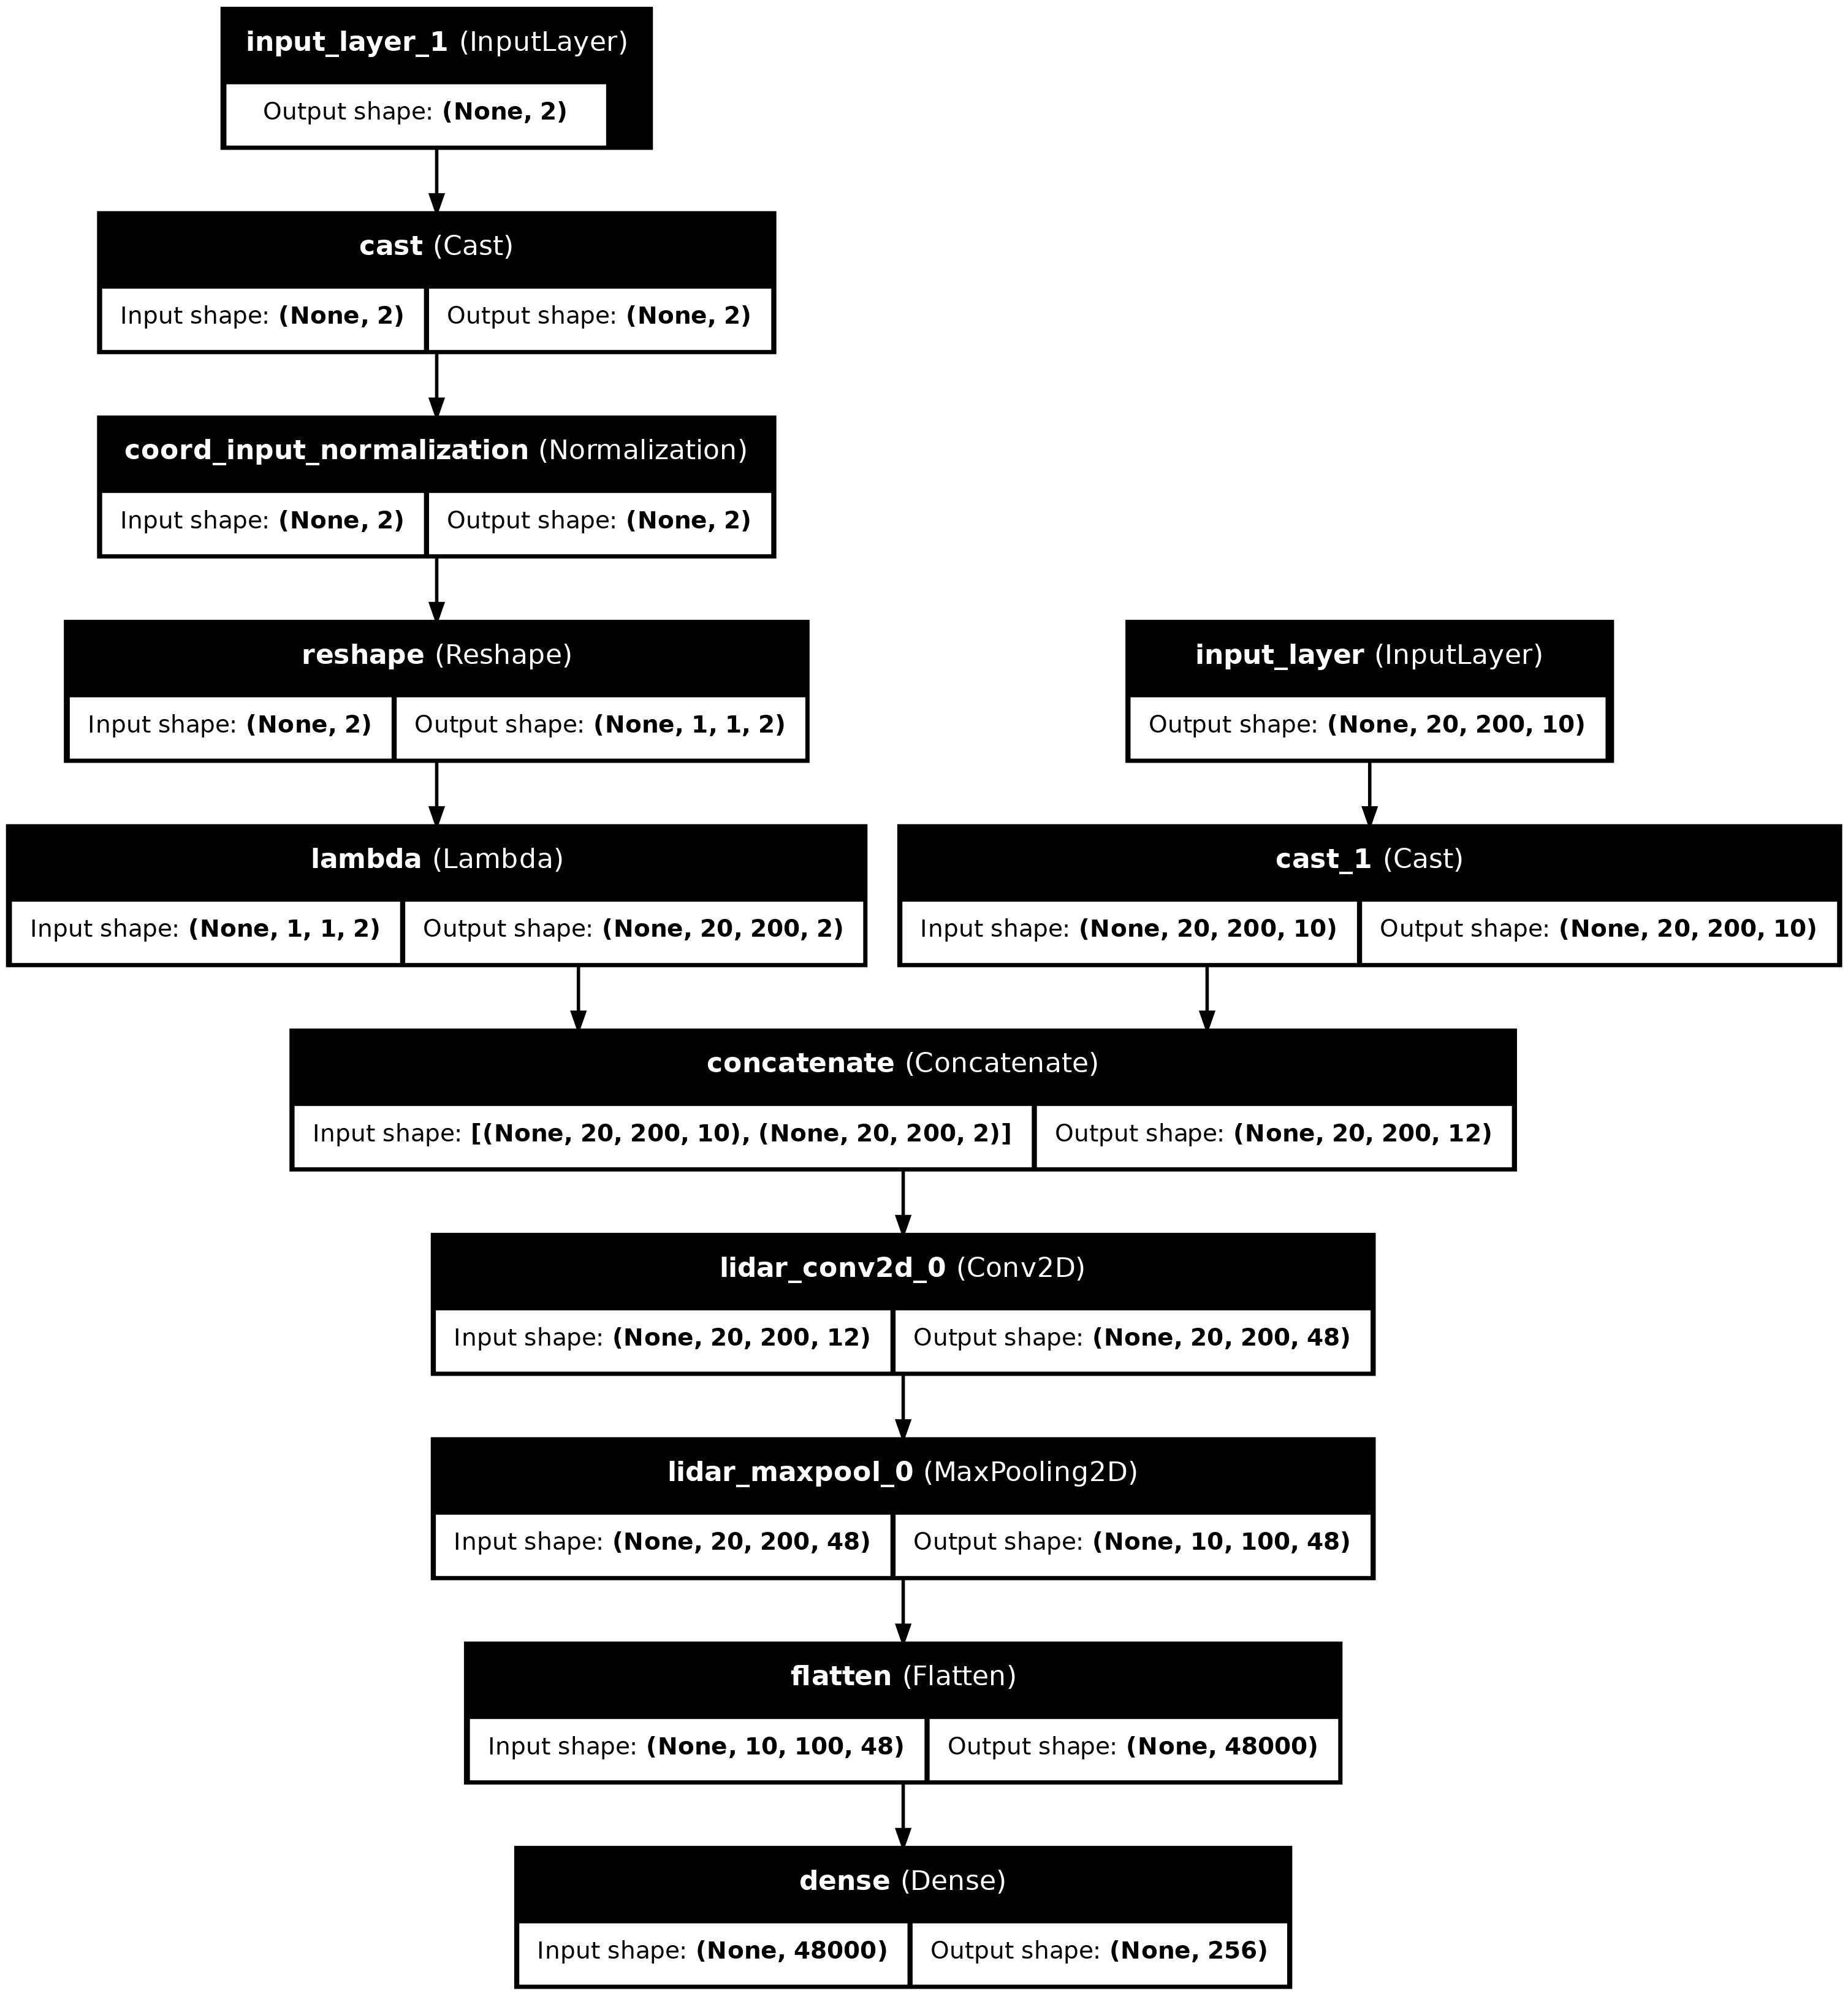

I0000 00:00:1745513711.238563   51446 service.cc:148] XLA service 0x74452c0170c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745513711.238603   51446 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2025-04-24 13:55:11.250894: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1745513711.293771   51446 cuda_dnn.cc:529] Loaded cuDNN version 90300


In [ ]:
try:
    # ——————————————————————————————— Storage paths —————————————————————————————— #
    study_dir = os.path.join(RUN_DIR, "optuna_study")
    os.makedirs(study_dir, exist_ok=True)

    dirs = {
        "args": os.path.join(study_dir, "args"),
        "figures": os.path.join(study_dir, "figures"),
        "weights": os.path.join(study_dir, "weights"),
        "models": os.path.join(study_dir, "models"),
    }
    for path in dirs.values():
        os.makedirs(path, exist_ok=True)

    storage_path = f"sqlite:///{os.path.join(study_dir, 'optuna_study.db')}"
    checkpoint_dir, model_dir, fig_dir, args_dir = (
        dirs["weights"],
        dirs["models"],
        dirs["figures"],
        dirs["args"],
    )

    print(f"Initializing study at '{study_dir}'...")
    
    # —————————————————————————————————— Pruners ————————————————————————————————— #
    pruner = optuna.pruners.HyperbandPruner()

    # ——————————————————————————————————— Study —————————————————————————————————— #
    study = optuna.create_study(
        study_name=os.path.basename(study_dir),
        storage=storage_path,
        direction="minimize", #? Tip: use multi-objective when NN size
        pruner=pruner,
        load_if_exists=True,
    )
    
    done_trials = len(study.get_trials(deepcopy=False, states=(optuna.trial.TrialState.COMPLETE,)))
    n_remaining_trials = max(0, NUM_TRIALS - done_trials)
    
    study.optimize(
        lambda trial: objective(
            trial,
            X=[s008_lidar_input, s008_coord_input],
            y=[s008_y_train],
            checkpoint_dir=checkpoint_dir,
            model_dir=model_dir,
            fig_dir=fig_dir,
            epochs=EPOCHS,
            
            #? "params": Penalizes the model based on the number of trainable parameters.
            #? "flops": Penalizes the model based on the number of floating-point operations.
            #? None: No size penalty is applied.
            size_penalizer=None,
            
            #? True: Adds regularization (e.g., L1/L2) to layers to prevent overfitting.
            #? False: No regularization is applied.
            use_regularization=False,
            
            #? "beside": Adds residual connections between consecutive layers.
            #? "all": Adds residual connections from all previous layers.
            #? None: No residual connections are applied.
            residual_method=None, #! Find your backbone first
        ),
        n_trials=n_remaining_trials,
        catch=(ValueError, RuntimeError),
        gc_after_trial=True,
        n_jobs=1, # If you have multiple GPUs/Cores
        show_progress_bar=False,
    )

    # ————————————————————————————— Save Top-K Trials ———————————————————————————— #
    valid_trials = [t for t in study.trials if t.value is not None]
    sorted_trials = sorted(valid_trials, key=lambda t: t.value)[:TOP_K]

    for rank, trial in enumerate(sorted_trials):
        trial_id = trial.number
        trial_params = trial.params
        trial_loss = trial.value
        trial_train_acc = trial.user_attrs.get("best_train_accuracy", None)
        trial_val_acc = trial.user_attrs.get("best_val_accuracy", None)
        trial_test_acc = trial.user_attrs.get("test_accuracy_s009", None)

        save_trial_params_to_file(
            filepath=os.path.join(args_dir, f"top_{rank + 1}_trial.txt"),
            params=trial_params,
            rank=rank + 1,
            trial_id=trial_id,
            loss=trial_loss,
            val_accuracy=trial_val_acc,
            train_accuracy=trial_train_acc,
            test_accuracy=trial_test_acc,
            sampler=study.sampler.__class__.__name__,
        )

    # —————————————————————————— Clean-Up Non-Top Trials ————————————————————————— #
    all_trial_ids = {t.number for t in study.trials}
    top_trial_ids = {t.number for t in sorted_trials}

    cleanup_paths = [
        (checkpoint_dir, "trial_{trial_id}.weights.h5"),
        (model_dir, "trial_{trial_id}.keras"),
        (fig_dir, "trial_{trial_id}.png"),
    ]

    for trial_id in all_trial_ids - top_trial_ids:
        for base_dir, filename_template in cleanup_paths:
            file_path = os.path.join(base_dir, filename_template.format(trial_id=trial_id))
            if os.path.exists(file_path):
                os.remove(file_path)

    analyze_study(study, fig_dir=fig_dir, table_dir=study_dir)

    failed_trials = sum(1 for t in study.trials if t.state != optuna.trial.TrialState.COMPLETE)
    notify_training_success(
        recipients_file="./json/recipients.json",
        credentials_file="./json/credentials.json",
        subject=f"🎉 Training Complete - Failed Trials: {failed_trials}",
    )

except Exception as e:
    print(f"An error occurred: {e}")
    traceback.print_exc()

In [ ]:
if _monitor_proc is not None and _monitor_proc.poll() is None:
    os.killpg(_monitor_proc.pid, signal.SIGINT)
    print(f"[INFO] Killed monitor group (PGID={_monitor_proc.pid}).")

[INFO] Killed monitor group (PGID=48962).
